# Practica sobre variable aleatoria

## Objetivos:
1. Evaluar diferentes condiciones necesarias y suficientes para el cumplimiento del Teorema del Límite Central.
2. Evaluar el concepto de ergocicidad en un proceso aleatorio. Para el caso específico del Movimiento Browniano.
3. Aplicar los conceptos de pruebas de hipótesis y normalidad para comparar grupos de datos.

## Teorema del Límite Central (TLC)

El Teorema del Límite Central establece que la suma (o promedio) de un número
grande de variables aleatorias independientes e idénticamente distribuidas (iid)
tiende a seguir una distribución Normal (Gaussiana), sin importar la distribución
original de cada variable.


## Distribución Uniforme $U[a, b]$

Para una VA Uniforme en el intervalo $[a, b]$, su función de densidad es constante:

$$f(x) = \frac{1}{b-a}, \quad a \leq x \leq b$$

con media y varianza:

$$\mu = \frac{a+b}{2}, \qquad \sigma^2 = \frac{(b-a)^2}{12}$$

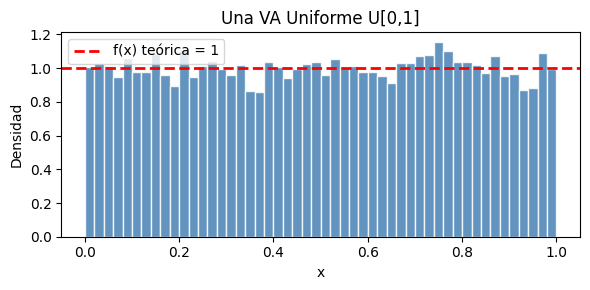

Media muestral:   0.5011  | Teórica: 0.5000
Std   muestral:   0.2887  | Teórica: 0.2887


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 10000
muestras_uniforme = np.random.uniform(0, 1, N)

plt.figure(figsize=(6, 3))
plt.hist(muestras_uniforme, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.85)
plt.axhline(1, color='red', linestyle='--', lw=2, label='f(x) teórica = 1')
plt.title('Una VA Uniforme U[0,1]')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Media muestral:   {muestras_uniforme.mean():.4f}  | Teórica: {(0+1)/2:.4f}")
print(f"Std   muestral:   {muestras_uniforme.std():.4f}  | Teórica: {np.sqrt((1-0)**2/12):.4f}")

## Distribución Exponencial

La distribución exponencial tiene la siguiente función de densidad:

$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

Con media y desviación estándar:

$$\mu = \sigma = \frac{1}{\lambda}$$

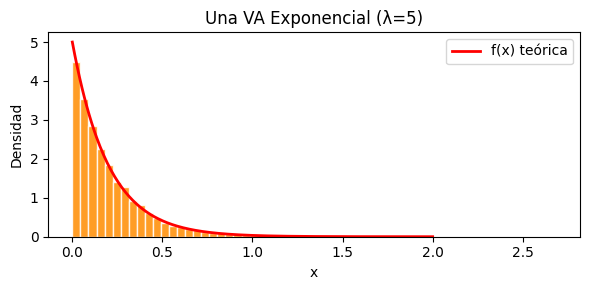

Media muestral: 0.2025 | Teórica: 0.2000
Std   muestral: 0.2046 | Teórica: 0.2000


In [ ]:
lam = 5
muestras_exp = np.random.exponential(scale=1/lam, size=N)

plt.figure(figsize=(6, 3))
plt.hist(muestras_exp, bins=60, density=True, color='darkorange', edgecolor='white', alpha=0.85)

x = np.linspace(0, 2, 300)
plt.plot(x, lam * np.exp(-lam * x), 'r-', lw=2, label=f'f(x) teórica')
plt.title(f'Una VA Exponencial (λ={lam})')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Media muestral: {muestras_exp.mean():.4f} | Teórica: {1/lam:.4f}")
print(f"Std   muestral: {muestras_exp.std():.4f} | Teórica: {1/lam:.4f}")

## Suma de VAs iid

Sean $X_1, X_2, \ldots, X_n$ VAs iid con media común $\mu$ y desviación estándar común $\sigma$. Particularmente nos interesa:

- Muestra total ($T$): $T = \sum_{i=1}^{n} X_i$
- Media muestral ($\bar{X}$): $\bar{X} = \frac{T}{n}$

$T$ y $\bar{X}$ tienen las siguientes propiedades:

|  | $T$ | $\bar{X}$ |
|--|-----|-----------|
| Media | $E[T] = n\mu$ | $E[\bar{X}] = \mu$ |
| Varianza | $\text{Var}(T) = n\sigma^2$ | $\text{Var}(\bar{X}) = \frac{\sigma^2}{n}$ |
| Desv. estándar | $\text{SD}(T) = \sqrt{n}\sigma$ | $\text{SD}(\bar{X}) = \frac{\sigma}{\sqrt{n}}$ |

Note que promediar pone los datos hacia el centro mientras que totalizar los dispersa.

El siguiente ejemplo ilustra esta diferencia para $n = 10$ VAs Uniformes $U[0,1]$ independientes a partir de 1000 realizaciones:

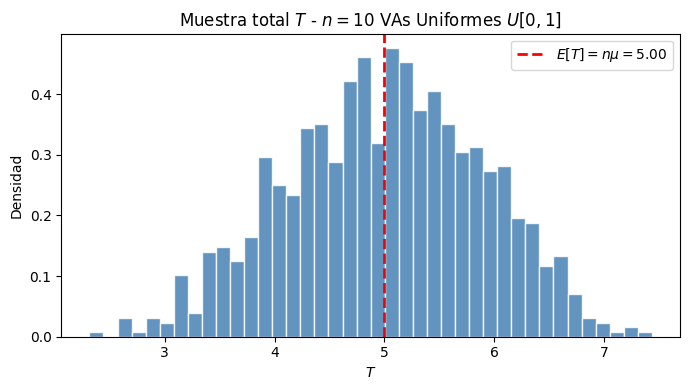

E[T]   estimada: 4.9997  | Teórica: 5.0000
Var(T) estimada: 0.8057  | Teórica: 0.8333


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N, n = 1000, 10
mu    = 0.5
sigma2 = (1**2) / 12

muestras = np.random.uniform(0, 1, size=(N, n))
T = muestras.sum(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(T, bins=40, density=True, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(n * mu, color='red', linestyle='--', lw=2, label=f'$E[T] = n\\mu = {n*mu:.2f}$')
plt.title(f'Muestra total $T$ - $n={n}$ VAs Uniformes $U[0,1]$')
plt.xlabel('$T$'); plt.ylabel('Densidad'); plt.legend()
plt.tight_layout()
plt.show()

print(f"E[T]   estimada: {T.mean():.4f}  | Teórica: {n * mu:.4f}")
print(f"Var(T) estimada: {T.var():.4f}  | Teórica: {n * sigma2:.4f}")

Ahora analicemos la media muestral de la suma de VAs.

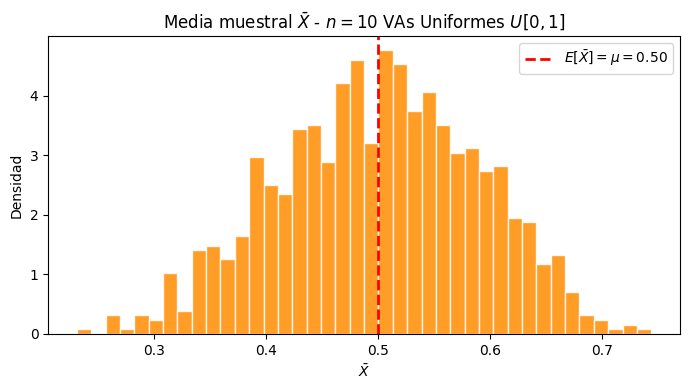

E[X_barra]   estimada: 0.5000  | Teórica: 0.5000
Var(X_barra) estimada: 0.0081  | Teórica: 0.0083


In [ ]:
X_barra = muestras.mean(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(X_barra, bins=40, density=True, color='darkorange', edgecolor='white', alpha=0.85)
plt.axvline(mu, color='red', linestyle='--', lw=2, label=f'$E[\\bar{{X}}] = \\mu = {mu:.2f}$')
plt.title(f'Media muestral $\\bar{{X}}$ - $n={n}$ VAs Uniformes $U[0,1]$')
plt.xlabel('$\\bar{X}$'); plt.ylabel('Densidad'); plt.legend()
plt.tight_layout()
plt.show()

print(f"E[X_barra]   estimada: {X_barra.mean():.4f}  | Teórica: {mu:.4f}")
print(f"Var(X_barra) estimada: {X_barra.var():.4f}  | Teórica: {sigma2/n:.4f}")


## Matriz de correlación de Pearson

El coeficiente de correlación de Pearson mide la dependencia lineal entre
dos variables. Para un par $(X_i, X_j)$:

$$\rho_{ij} = \frac{\text{Cov}(X_i, X_j)}{\sigma_i \cdot \sigma_j} \in [-1, 1]$$

| Valor de $\rho$. | Interpretación |
|----|----|
| $\rho \approx 1$ | Correlación positiva fuerte |
| $\rho \approx 0$ | Variables NO correlacionadas linealmente |
| $\rho \approx -1$ | Correlación negativa fuerte |

Cuando tenemos $n$ variables, podemos organizar todos los coeficientes en una
matriz de correlación $\mathcal{P} \in \mathbb{R}^{n\times n}$, donde:

- La diagonal principal siempre es 1 (cada variable consigo misma)
- La matriz es simétrica: $\rho_{ij} = \rho_{ji}$

Para variables independientes, esperamos que cada $\rho \in \mathcal{P}$ se aproxime a la matriz identidad; sin embargo, recuerde que $\rho=0$ no garantiza independencia.

Ahora, vamos a generar una matriz de correlación entre 10 VAs uniformes generadas en 1000 realizaciones.

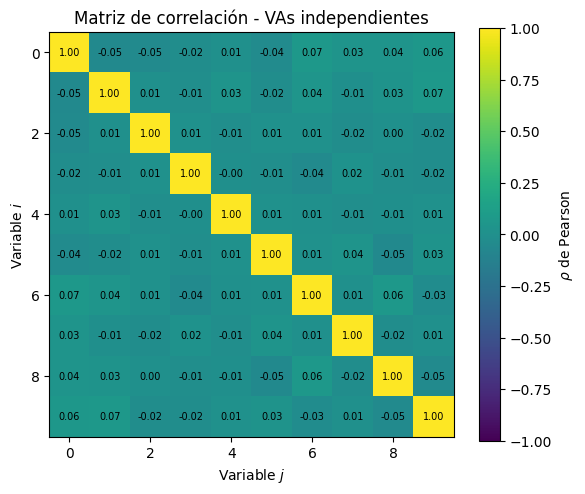

Correlación promedio entre pares: 0.0030
(Esperado ≈ 0 para variables independientes)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

N = 1000  # realizaciones
n = 10    # número de variables

# Generamos n VAs Uniformes independientes → shape (N, n)
muestras = np.random.uniform(0, 1, size=(N, n))

# Calculamos la matriz de correlación de Pearson [n x n]
R = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        r, _ = pearsonr(muestras[:, i], muestras[:, j])
        R[i, j] = r

# Visualización
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(R, vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label=f'$\\rho$ de Pearson')

# Anotamos cada celda con su valor
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{R[i,j]:.2f}', ha='center', va='center', fontsize=7, color='black')

ax.set_title('Matriz de correlación - VAs independientes')
ax.set_xlabel('Variable $j$')
ax.set_ylabel('Variable $i$')
plt.tight_layout()
plt.show()

# Correlación promedio fuera de la diagonal
mask = ~np.eye(n, dtype=bool)
print(f"Correlación promedio entre pares: {R[mask].mean():.4f}")
print(f"(Esperado ≈ 0 para variables independientes)")


## Procesos Aleatorios

Un proceso aleatorio $X(t)$ es una colección de variables aleatorias
indexadas por el tiempo. Para cada instante $t$ fijo, $X(t)$ es una VA.
Para cada realización fija, $X(t)$ es una función determinista del tiempo.

Podemos estudiarlo desde dos perspectivas:

| Perspectiva | Descripción |
|---|---|
| **Media del ensamble** | Valor esperado sobre todas las realizaciones en un instante $t$ fijo |
| **Media temporal** | Valor esperado a lo largo del tiempo para una realización fija |



---
# **Laboratorio**
---

# Punto 1: Teorema del límite central




La media ($\mu$) y la desviación estándar ($\sigma$) de una Variable Aleatoria (VA) Uniforme ~ [a,b] está dada por la expresión: $\mu = \frac{a+b}{2}$ y $\sigma^2 = \frac{1}{12}(b-a)^2$.


1.1. Considere la suma de $n$ distribuciones con $n \in \{2,5,100,1000\}$ y grafique el histograma resultante para cada caso.

1.2. ¿Cuál es la distribución resultante del punto 1? Estime la media y la desviación estándar del resultado de la suma.
Compare con el caso teórico del punto anterior.

1.3. Considere ahora una VA exponencial, cuya distribución es: $F(\lambda)=\lambda e^{-\lambda x}$, con $\lambda=5$.
Realice el mismo procedimiento que realizó con las VA Uniformes y obtenga la media y desviación estandar, teniendo en cuenta que: $\mu = \sigma = \frac{1}{λ}$. Describa el comportamiento que se observa al realizar la suma de las $n$ distribuciones exponenciales.

1.4. Realice lo indicado en el ítem 1.2 para este caso con exponenciales.
Compare el resultado con VAs uniformes vs. VA exponenciales y concluya.


# Punto 2:





### **Suma de VAs**

2.1. Considere 120 distribuciones uniformes, en grupos de 20 con diferentes valores de a y b por grupo, i.e., no son iid. Muestre que la suma total converge a una distribución Gaussiana después de 1000 realizaciones. Y analice si es posible encontrar valores teóricos de $\mu$ y $\sigma$. Concluya.

### **Suma de VAs con diferentes distribuciones (Uniforme, Exponencial, Gaussiana)**

2.2. Considere ahora 1000 realizaciones de 30 distribuciones, así: 10 Uniformes, 10 Exponenciales, y 10 Gaussianas. Use a=10 y b=20, $\lambda=5$, y $\mu =30$, $\sigma=5$. Muestre que el ensamble converge a una distribución Gaussiana. Calcule la media y la desviación estándar del ensamble resultante. Concluya.

### **Suma de VAs correlacionadas**

2.3.  Suma de VAs correlacionadas:

*   Genere un conjunto de 20 VAs **correlacionadas** con 1000 realizaciones. Use dos variables exponenciales base para construir dos grupos de 10 VAs cada uno mediante transformaciones lineales.


* Encuentre el ensamble (suma o promedio de las 20 VAs), grafique y compare. ¿Qué puede concluir con la información que ha encontrado hasta ahora?

* Calcule ahora, la matriz de correlación de Pearson $\mathcal{P}$ (usando la función `pearsonr`) para las 20 distribuciones. Deberá encontrar una matriz de $[20 \times 20]$. ¿Qué estructura espera observar? ¿Qué puede concluir ahora?


# Punto 3: Procesos aleatorios



## 3.1. Señal cosenoidal con fase aleatoria

3.1.1 Genere N arreglos del proceso aleatorio $cos(2 \pi f_c t + Φ) + 1$ donde $Φ \thicksim U [0,2\pi]$ y grafique al menos 5 de ellos en una figura.

3.1.2 Varíe el número de arreglos entre [10, 100, 1000], calcule la media a travez del ensamble para cada tiempo y grafique el resultado. Qué puede concluir del comportamiento de la media del ensamble al variar la cantidad de arreglos generados del proceso aleatorio?

3.1.3 Calcule la media temporal para cada arreglo y grafique el resultado. Qué puede inferir del proceso aleatorio?



# Punto 4: Procesos aleatorios y ergodicidad, caso del movimiento browniano.

4.1. Considere la función "brownian motion(M,T)" donde M=1000 y T=10. Genere el ensamble del proceso aleatorio, dibújelo y calcule la media del ensamble (para todas las filas del ensamble) y la media temporal (para todas las columnas). Qué puede concluir?




In [ ]:
def brownian_motion(M,T):
  # M: Numero de puntos en el eje temporal

  dt = T / M  # Time step

  # Simulate multiple realizations of Brownian motion

  # Generate the increments for Brownian motion
  dW = np.random.normal(0, np.sqrt(dt), M-1)
  W_t = np.concatenate(([0], np.cumsum(dW)))  # Inicia en W(0) = 0 y accumacumula los incrementos
  return W_t



# Punto 5: Calidad de Señal en una Red Inalámbrica WiFi

---

### Contexto general

Una empresa de telecomunicaciones está evaluando la migración de su infraestructura interna de **WiFi 5** a **WiFi 6**. Para apoyar esta decisión con evidencia estadística, se realizaron mediciones en **90 puntos fijos** distribuidos en tres pisos de un edificio de oficinas. En cada punto se registraron las mismas variables con ambas tecnologías.

Los datos se encuentran en dos archivos CSV: `wifi5_datos.csv` y `wifi6_datos.csv`

Ambos archivos contienen **exactamente los mismos 90 puntos de medición** (`punto_id` del 1 al 90) con las siguientes columnas:


* `punto_id`: Identificador único del punto de medición
* `piso`: Piso del edificio: `Piso1`, `Piso2` o `Piso3`
* `rssi_dbm`:  Potencia de señal recibida en dBm
* `intermitencia`: Intermitencia de servicio registrada: `Si` o `No`

**Nota:** El RSSI (*Received Signal Strength Indicator*) mide la potencia de la señal en dBm. Valores más cercanos a 0 son mejores.

Referencia orientativa:

* 0 dbm: señal ideal, difícil de lograr en la práctica.
* -40 a -60 dBm: señal idónea con tasas de transferencia estables.
* -60 dBm: enlace bueno.
* -70 dBm: enlace medio-bajo.
* 80 dBm: es la señal mínima aceptable para establecer la conexión.

---


## 5.1 — Comparación Global del RSSI: WiFi 5 vs. WiFi 6

El equipo de ingeniería quiere saber si, **considerando todo el edificio en conjunto**, existe alguna diferencia en la calidad de señal entre ambas tecnologías.

Los 90 puntos físicos son los mismos para ambas tecnologías. En este punto se tratarán las muestras como **independientes** para el análisis comparativo entre grupos.



### 5.1.1 — Análisis exploratorio: histogramas y estadísticos descriptivos

Antes de aplicar cualquier prueba estadística, es fundamental entender visualmente cómo se distribuyen los datos.

**Procedimiento:**
- Construya y presente una tabla que incluya las siguientes columnas: media, mediana, desviación estándar, varianza, mínimo y máximo del RSSI para cada tecnología.
- Grafique en una sola figura el histograma de `rssi_dbm` para WiFi5 y WiFi6 (un color diferente por tecnología). Agregue líneas verticales indicando la media de cada grupo.
- Grafique el diagrama de cajas y bigotes (boxplot) en una sola figura para la variable `rssi_dbm` usando los datos de las tecnologías WiFi5 y WiFi6 (un color diferente por tecnología)


**Preguntas:**
- ¿Con base únicamente en los estadísticos y las distribuciones se puede concluir si las tecnologías son similares o distintas?



### 5.1.2 Pruebas estadísticas:

*   Determine si las varianzas de ambos grupos son iguales (cumplen el criterio de homocedasticidad). Para ello utilice la prueba Levene usando la libreria `scipy.stats.levene`.
*   Determine si las medias de ambos grupos son iguales. Para esto, primero determine si los dos grupos siguen una distribución normal mediante la prueba `scipy.stats.shapiro`, luego aplique `scipy.stats.ttest_ind` o `scipy.stats.mannwhitneyu` de acuerto con el resultado de la prueba de normalidad.

**NOTA:** Lea la documentación de cada prueba, identificando la hipótesis nula en cada caso, y el criterio para aceparla o rechazarla. Adicionalmente, para las pruebas `scipy.stats.ttest_ind` y `scipy.stats.mannwhitneyu` busque el significado del parámetro `alternative` asociado a los tipos de "colas".


**Preguntas:**
- ¿Existe diferencia estadísticamente significativa entre el RSSI de WiFi5 y WiFi6 a nivel global?
- ¿Este resultado global es suficiente para tomar la decisión de migración? ¿O podría haber información importante que se esté perdiendo al visualizar las pruebas de manera global?



---
## 5.2 — Análisis por Piso: Comparación de RSSI entre Tecnologías

El punto 5.1 ofreció una visión global del edificio. Sin embargo, un ingeniero de redes sabe que la cobertura puede variar significativamente según la zona.

Repita **exactamente el mismo análisis** para las tecnologías WiFI5 y WiFi6 (dssi_dbm) pero aplicado de forma **independiente para cada piso**.



### 5.2.1 — Análisis exploratorio por piso

**procedimiento:**
- Grafique un **boxplot y distribuciones** del `rssi_dbm` para cada piso, mostrando WiFi5 y WiFi6 lado a lado.
- Calcule media, desviación estándar y varianza del RSSI para cada combinación piso-tecnología.

**Preguntas:**
- ¿Visualmente, en qué pisos parece haber diferencia entre las medias de WiFi5 y WiFi6? ¿En cuáles parecen similares?


### 5.2.2 — test comparativo por cada piso

* Para cada piso (**Piso1, Piso2, Piso3**) de forma independiente, realice las pruebas estadisticas para determinar si las varianzas y las medias son similares:






## 5.3 — Asociación entre Tecnología e Intermitencias de Servicio

El departamento de TI registró si cada punto de medición presentó **intermitencias de servicio** (caídas de conexión, latencia elevada, etc.) durante la semana de mediciones. La columna `intermitencia` toma los valores `Si` o `No`.

Se quiere determinar si existe asociación estadística entre la tecnología utilizada y la ocurrencia de intermitencias. El análisis se realizará en **dos niveles**: primero globalmente y luego por piso.

Tanto `tecnologia` como `intermitencia` son **variables categóricas**.


### 5.3.1 — Análisis global: tabla de contingencia y exploración

Considere todos los 180 registros (90 de WiFi5 + 90 de WiFi6) en conjunto, sin distinguir por piso.

**Instrucciones:**
- Construya una **tabla de contingencia 2×2** cruzando `tecnologia` (WiFi5 / WiFi6) vs. `intermitencia` (Si / No). Reporte las frecuencias. Utlice la función `pd.crosstab`.

- Grafique las frecuencias en dos gráficos de barras.

**Preguntas:**
- ¿A primera vista, las tasas de intermitencia de WiFi5 y WiFi6 parecen similares o muy diferentes a nivel global?

### 5.3.2 — Pruebas estadisticas

**Procedimineto:**
- Determine si existe una asociación estadísticamente significativa entre la tecnología y las intermitencias a nivel global. Para ello, utilice la prueba `stats.chi2_contingency` con base en la tabla de contingencia.


## 5.4 — Asociación entre Tecnología e Intermitencias de Servicio por piso

5.4.1: Realice un grafico de barras donde se evidencien la cantidad de intermitecias por tecnología en cada piso de manera independiente.

5.4.2: Aplique una prueba estadistica por piso para determinar si existe una asociación estadisticamente significativa entre tecnología e intermitencias en el servicio.